In [1]:
import numpy as np
import pandas as pd

In [2]:
df_1=pd.read_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\updated_data.csv")

In [3]:
df_2=pd.read_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\updated_semantic_data.csv")

In [4]:
df_1.head()

,question,documents,response,sentence_support_information,label
0,What role does T-cell count play in severe hum...,['Title: Emergent severe acute respiratory dis...,The T-cell count plays a crucial role in sever...,[{'explanation': 'This sentence is supported b...,GROUNDED
1,What is MVO?,['Title: Gene Knockdowns in Adult Animals: PPM...,MVO is not defined or mentioned in the provide...,[{'explanation': 'The sentence correctly state...,GROUNDED
2,What have sero-surveys of MERS virus found?,"['Title: MERS coronavirus: diagnostics, epidem...",Sero-surveys of MERS virus found no sign of ME...,[{'explanation': 'This sentence is partly supp...,PARTIALLY_GROUNDED
3,How were untreated MDA-MB-231 cells labeled?,['Title: Kinome-Wide siRNA Screening Identifie...,The untreated MDA-MB-231 cells were labeled wi...,[{'explanation': 'The sentence is fully suppor...,GROUNDED
4,What is the number of inhabitants of Reunion I...,['Title: Pandemic Influenza Due to pH1N1/2009 ...,"Reunion Island has a population of 850,000 inh...",[{'explanation': 'This sentence claims that Re...,GROUNDED


In [5]:
df_2.head()

,label,response_embeddings,document_embeddings,question_embeddings,doc_response_similarity,question_response_similarity,question_document_similarity
0,GROUNDED,[ 9.64630209e-03 3.33776027e-02 1.66789331e-...,[-2.88786087e-02 2.87237838e-02 7.56983936e-...,[-3.22162621e-02 2.47374829e-02 -1.71899684e-...,0.782924,0.901967,0.729742
1,GROUNDED,[-3.62419002e-02 -3.03612615e-04 -2.93646846e-...,[-5.43885157e-02 -7.26703554e-03 -8.73105507e-...,[-2.26425249e-02 -4.85397736e-03 -6.18805736e-...,0.211373,0.701803,0.096944
2,PARTIALLY_GROUNDED,[ 8.70998949e-02 8.42432529e-02 -2.45561693e-...,[-6.24402775e-04 1.15105011e-01 -6.74891472e-...,[-2.41323262e-02 5.54744676e-02 -3.50597836e-...,0.825851,0.716620,0.649443
3,GROUNDED,[-4.43644524e-02 -5.05170338e-02 -1.04717642e-...,[-3.21069025e-02 -8.86590183e-02 -1.38417780e-...,[-2.07818262e-02 4.40060645e-02 -1.34034619e-...,0.583459,0.641136,0.506321
4,GROUNDED,[ 3.64738293e-02 -7.47442544e-02 2.30430868e-...,[ 2.12941747e-02 -1.13025522e-02 2.27199793e-...,[ 3.45350206e-02 -3.44853997e-02 2.92823091e-...,0.306352,0.847259,0.340603


In [6]:
df_1=df_1.drop("sentence_support_information",axis=1)

In [7]:
df_1.columns

Index(['question', 'documents', 'response', 'label'], dtype='str')

In [8]:
df_2.columns

Index(['label', 'response_embeddings', 'document_embeddings',
       'question_embeddings', 'doc_response_similarity',
       'question_response_similarity', 'question_document_similarity'],
      dtype='str')

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
def get_tfidf_sim(text_a, text_b_series, vectorizer):
    sims = []
    for a, b in zip(text_a, text_b_series):
        tfidf = vectorizer.transform([a, b])
        sims.append(cosine_similarity(tfidf[0], tfidf[1])[0][0])
    return np.array(sims)

In [11]:
corpus = pd.concat([df_1['question'], df_1['documents'], df_1['response']]).astype(str)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_vectorizer.fit(corpus)

,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'


In [12]:
df_1['tfidf_doc_response_sim'] = get_tfidf_sim(
    df_1['documents'].astype(str), df_1['response'].astype(str), tfidf_vectorizer
)

In [13]:
df_1['tfidf_question_response_sim'] = get_tfidf_sim(
    df_1['question'].astype(str), df_1['response'].astype(str), tfidf_vectorizer
)

In [14]:
df_1['tfidf_question_document_sim'] = get_tfidf_sim(
    df_1['question'].astype(str), df_1['documents'].astype(str), tfidf_vectorizer
)

In [15]:
import re

def numeric_overlap(response, documents):
    resp_nums = set(re.findall(r'\d+\.?\d*', str(response)))
    doc_nums = set(re.findall(r'\d+\.?\d*', str(documents)))
    if not resp_nums:
        return 1.0  # no numbers claimed, nothing to hallucinate
    return len(resp_nums & doc_nums) / len(resp_nums)

df_1['numeric_overlap'] = df_1.apply(
    lambda row: numeric_overlap(row['response'], row['documents']), axis=1
)

In [16]:
features = pd.concat([
    df_2[['doc_response_similarity', 'question_response_similarity', 'question_document_similarity']].reset_index(drop=True),
    df_1[['tfidf_doc_response_sim', 'tfidf_question_response_sim', 'tfidf_question_document_sim', 'numeric_overlap',"label"]].reset_index(drop=True)
], axis=1)

In [17]:
features=features.dropna()

In [18]:
labels = features['label'].reset_index(drop=True)

In [19]:
features=features.drop("label",axis=1)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

In [34]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

Accuracy: 0.44962256238205073
Macro F1: 0.4195218514489744
                    precision    recall  f1-score   support

          GROUNDED       0.58      0.32      0.42      9457
      HALLUCINATED       0.56      0.55      0.55      8115
PARTIALLY_GROUNDED       0.18      0.70      0.29      1504

          accuracy                           0.45     19076
         macro avg       0.44      0.53      0.42     19076
      weighted avg       0.54      0.45      0.46     19076



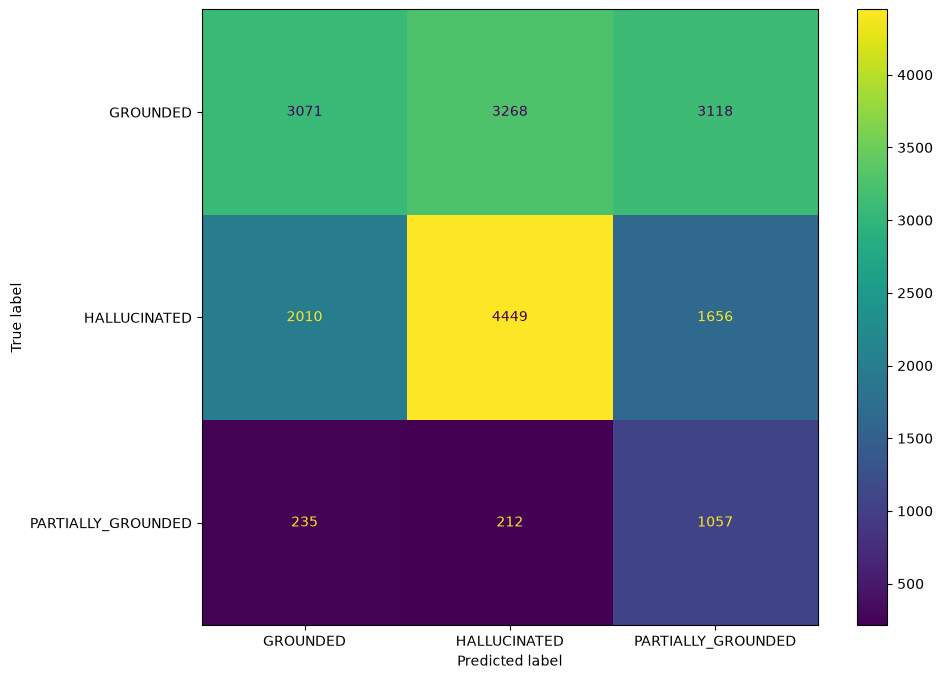

In [23]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "HALLUCINATED", "PARTIALLY_GROUNDED"]
)

disp.plot(ax=ax)

plt.show()

In [24]:
from sklearn.svm import LinearSVC

Accuracy: 0.5202872719647725
Macro F1: 0.4610885161712018
                    precision    recall  f1-score   support

          GROUNDED       0.57      0.53      0.55      9457
      HALLUCINATED       0.57      0.53      0.55      8115
PARTIALLY_GROUNDED       0.22      0.40      0.28      1504

          accuracy                           0.52     19076
         macro avg       0.45      0.49      0.46     19076
      weighted avg       0.54      0.52      0.53     19076



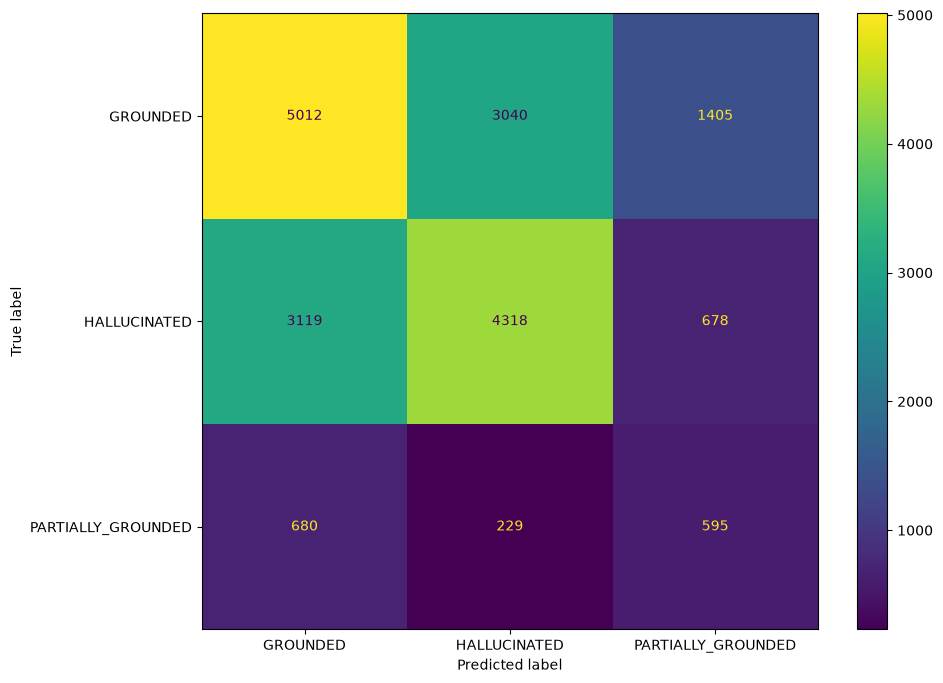

In [25]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        svm_pred,
        average="macro"
    )
)

print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "HALLUCINATED", "PARTIALLY_GROUNDED"]
)

disp.plot(ax=ax)

plt.show()

Accuracy: 0.5838750262109457
Macro F1: 0.473451957993845
                    precision    recall  f1-score   support

          GROUNDED       0.60      0.66      0.63      9457
      HALLUCINATED       0.61      0.57      0.59      8115
PARTIALLY_GROUNDED       0.23      0.18      0.20      1504

          accuracy                           0.58     19076
         macro avg       0.48      0.47      0.47     19076
      weighted avg       0.58      0.58      0.58     19076



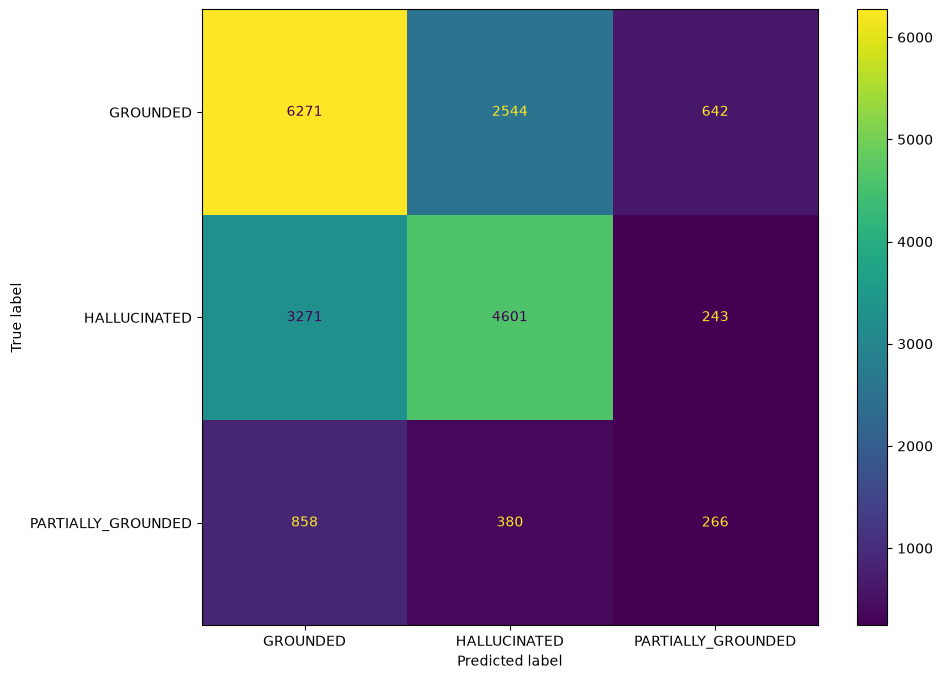

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=51,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        rf_pred,
        average="macro"
    )
)

print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "HALLUCINATED", "PARTIALLY_GROUNDED"]
)

disp.plot(ax=ax)

plt.show()


In [27]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,stratify=labels)

In [29]:
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

Accuracy: 0.6153281610400503
Macro F1: 0.41924225681131366
              precision    recall  f1-score   support

           0       0.59      0.81      0.68      9457
           1       0.66      0.50      0.57      8115
           2       0.14      0.00      0.00      1504

    accuracy                           0.62     19076
   macro avg       0.47      0.44      0.42     19076
weighted avg       0.59      0.62      0.58     19076



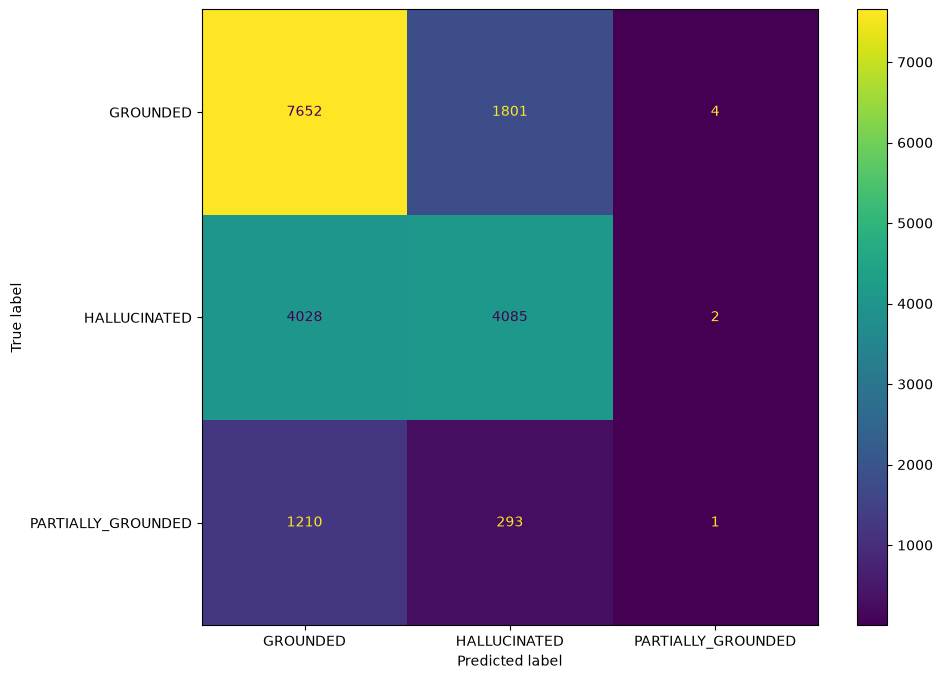

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train_encoded)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test_encoded, xgb_pred))

print(
    "Macro F1:",
    f1_score(
        y_test_encoded,
        xgb_pred,
        average="macro"
    )
)

print(classification_report(y_test_encoded, xgb_pred))

cm = confusion_matrix(y_test_encoded, xgb_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "HALLUCINATED", "PARTIALLY_GROUNDED"]
)

disp.plot(ax=ax)

plt.show()

In [31]:
# import joblib
# import os
# os.makedirs("save_model", exist_ok=True)
# joblib.dump(rf, "save_model/model.joblib")

In [16]:
df_2.columns

Index(['label', 'response_embeddings', 'document_embeddings',
       'question_embeddings', 'doc_response_similarity',
       'question_response_similarity', 'question_document_similarity'],
      dtype='str')

In [17]:
df_1.columns

Index(['question', 'documents', 'response', 'label', 'tfidf_doc_response_sim',
       'tfidf_question_response_sim', 'tfidf_question_document_sim',
       'numeric_overlap'],
      dtype='str')

In [18]:
features_2=pd.concat([
    df_2[['doc_response_similarity', 'question_response_similarity', 'question_document_similarity','response_embeddings', 'document_embeddings','question_embeddings']].reset_index(drop=True),
    df_1[['tfidf_doc_response_sim', 'tfidf_question_response_sim', 'tfidf_question_document_sim', 'numeric_overlap',"label"]].reset_index(drop=True)
], axis=1)

In [19]:
features_2.isnull().sum()

doc_response_similarity           0
question_response_similarity      0
question_document_similarity      0
response_embeddings               0
document_embeddings               0
question_embeddings               0
tfidf_doc_response_sim          208
tfidf_question_response_sim     208
tfidf_question_document_sim     208
numeric_overlap                 208
label                           208
dtype: int64

In [20]:
features_2.shape

(95586, 11)

In [21]:
features_2=features_2.dropna()

In [22]:
features_2.shape

(95378, 11)

In [23]:
features_2.head()

,doc_response_similarity,question_response_similarity,question_document_similarity,response_embeddings,document_embeddings,question_embeddings,tfidf_doc_response_sim,tfidf_question_response_sim,tfidf_question_document_sim,numeric_overlap,label
0,0.782924,0.901967,0.729742,[ 9.64630209e-03 3.33776027e-02 1.66789331e-...,[-2.88786087e-02 2.87237838e-02 7.56983936e-...,[-3.22162621e-02 2.47374829e-02 -1.71899684e-...,0.690887,0.761248,0.539978,1.0,GROUNDED
1,0.211373,0.701803,0.096944,[-3.62419002e-02 -3.03612615e-04 -2.93646846e-...,[-5.43885157e-02 -7.26703554e-03 -8.73105507e-...,[-2.26425249e-02 -4.85397736e-03 -6.18805736e-...,0.124988,0.000000,0.000000,1.0,GROUNDED
2,0.825851,0.716620,0.649443,[ 8.70998949e-02 8.42432529e-02 -2.45561693e-...,[-6.24402775e-04 1.15105011e-01 -6.74891472e-...,[-2.41323262e-02 5.54744676e-02 -3.50597836e-...,0.746806,0.539891,0.549671,1.0,PARTIALLY_GROUNDED
3,0.583459,0.641136,0.506321,[-4.43644524e-02 -5.05170338e-02 -1.04717642e-...,[-3.21069025e-02 -8.86590183e-02 -1.38417780e-...,[-2.07818262e-02 4.40060645e-02 -1.34034619e-...,0.441728,0.754792,0.396237,1.0,GROUNDED
4,0.306352,0.847259,0.340603,[ 3.64738293e-02 -7.47442544e-02 2.30430868e-...,[ 2.12941747e-02 -1.13025522e-02 2.27199793e-...,[ 3.45350206e-02 -3.44853997e-02 2.92823091e-...,0.342755,0.526879,0.444616,1.0,GROUNDED


In [29]:
label_2=features_2["label"]

KeyError: 'label'

In [25]:
features_2=features_2.drop("label",axis=1)

In [27]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    features_2, label_2, test_size=0.2, random_state=42, stratify=label_2
    )

In [31]:
import numpy as np

def parse_embedding(x):
    if isinstance(x, str):
        return np.fromstring(x.strip("[]"), sep=" ")
    return np.asarray(x, dtype=np.float32)


for col in [
    "question_embeddings",
    "document_embeddings",
    "response_embeddings"
]:
    X_train[col] = X_train[col].apply(parse_embedding)
    X_test[col] = X_test[col].apply(parse_embedding)

In [32]:
X_train = np.hstack([
    np.vstack(X_train["question_embeddings"]),
    np.vstack(X_train["document_embeddings"]),
    np.vstack(X_train["response_embeddings"])
])

X_test = np.hstack([
    np.vstack(X_test["question_embeddings"]),
    np.vstack(X_test["document_embeddings"]),
    np.vstack(X_test["response_embeddings"])
])

print(X_train.shape)
print(X_test.shape)
print(X_train.dtype)

(76302, 1152)
(19076, 1152)
float64


Accuracy: 0.6267037114699099
Macro F1: 0.5690105511881466
                    precision    recall  f1-score   support

          GROUNDED       0.76      0.58      0.66      9457
      HALLUCINATED       0.82      0.67      0.74      8115
PARTIALLY_GROUNDED       0.20      0.71      0.31      1504

          accuracy                           0.63     19076
         macro avg       0.60      0.65      0.57     19076
      weighted avg       0.74      0.63      0.66     19076



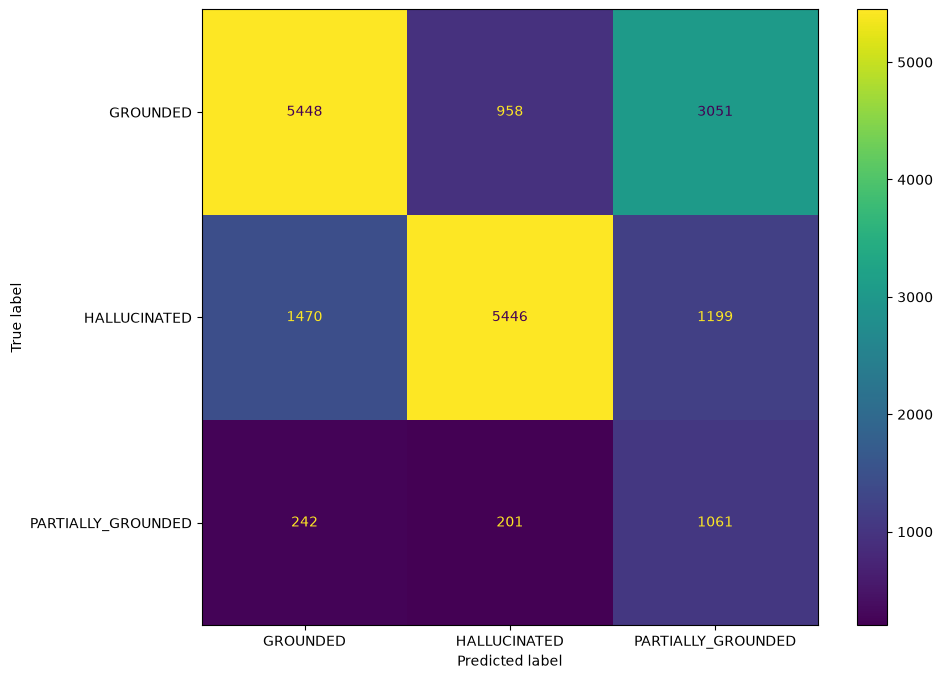

In [35]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "HALLUCINATED", "PARTIALLY_GROUNDED"]
)

disp.plot(ax=ax)

plt.show()

In [37]:
from sklearn.svm import LinearSVC

Accuracy: 0.692598028936884
Macro F1: 0.5888870712664729
                    precision    recall  f1-score   support

          GROUNDED       0.73      0.74      0.74      9457
      HALLUCINATED       0.84      0.69      0.76      8115
PARTIALLY_GROUNDED       0.21      0.39      0.27      1504

          accuracy                           0.69     19076
         macro avg       0.59      0.61      0.59     19076
      weighted avg       0.73      0.69      0.71     19076



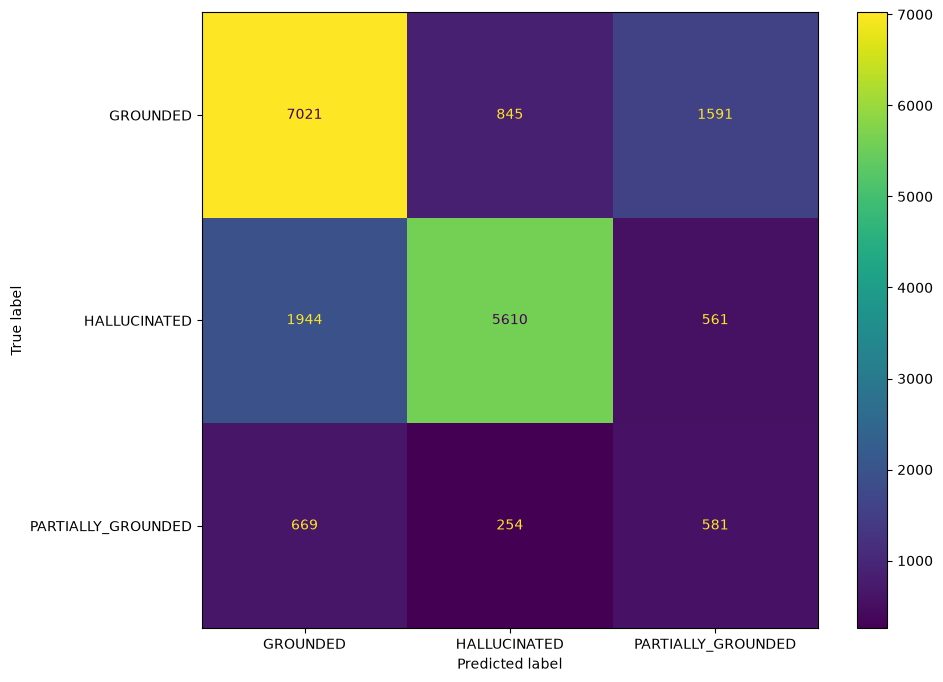

In [38]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        svm_pred,
        average="macro"
    )
)

print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "HALLUCINATED", "PARTIALLY_GROUNDED"]
)

disp.plot(ax=ax)

plt.show()

In [39]:
import joblib
import os
os.makedirs("save_model", exist_ok=True)
joblib.dump(model, "save_model/model.joblib")

['save_model/model.joblib']